In [1]:
import geopandas as gpd
import pandas as pd
from blocksnet.config import log_config

log_config.set_logger_level('WARNING')

# Оценка стоимости земли проекта

In [2]:
scenario_blocks = pd.read_pickle('../data/scenario_blocks.pickle')
scenario_blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share
0,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,LandUse.AGRICULTURE,0.918180
1,"POLYGON ((388558.037 6645102.374, 388511.373 6...",0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,LandUse.BUSINESS,0.938081
2,"POLYGON ((387957.434 6643444.937, 388007.492 6...",0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,LandUse.TRANSPORT,0.891381
3,"POLYGON ((388007.492 6643608.409, 387957.434 6...",0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,LandUse.RESIDENTIAL,0.934862
4,"POLYGON ((388001.306 6643195.969, 388000.75 66...",0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN


In [3]:
blocks = pd.read_pickle('../data/prepared_blocks.pickle')
blocks.head()

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,site_area,fsi,gsi,mxi,l,morphotype,area_accessibility,is_scn,geometry,id
0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.91818,AGRICULTURE,0.918180,6260.339339,...,202399.732193,0.062008,0.030931,0.000000,2.004749,low-rise non-residential,83.073985,True,"POLYGON ((388511.373 6644951.946, 388558.037 6...",0
1,0.000000,0.938081,0.0,0.0,0.000000,0.0,0.00000,BUSINESS,0.938081,18143.803825,...,201529.493481,0.202340,0.090031,0.000000,2.247463,low-rise non-residential,82.652504,True,"POLYGON ((388558.037 6645102.374, 388511.373 6...",1
2,0.000000,0.000000,0.0,0.0,0.891381,0.0,0.00000,TRANSPORT,0.891381,15011.639457,...,164663.859830,0.151737,0.091165,0.000000,1.664418,low-rise non-residential,109.288479,True,"POLYGON ((387957.434 6643444.937, 388007.492 6...",2
3,0.934862,0.000000,0.0,0.0,0.000000,0.0,0.00000,RESIDENTIAL,0.934862,22467.050757,...,161571.832511,0.449142,0.139053,0.404539,3.230005,low-rise model,112.015000,True,"POLYGON ((388007.492 6643608.409, 387957.434 6...",3
4,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.00000,None,NaN,0.316008,...,16.489152,0.079224,0.019165,0.000000,4.133894,mid-rise non-residential,82.790797,True,"POLYGON ((388001.306 6643195.969, 388000.75 66...",4


In [4]:
from catboost import CatBoostRegressor

from urbanomy.methods.land_value_modeling import LandPriceEstimator

model = CatBoostRegressor()
model.load_model('../data/catboost_model.cbm')  # модель на лог-цене

estimator = LandPriceEstimator(
    model=model,
    blocks=blocks,
)
blocks_pred = estimator.predict()



# Визуализация стоимости земли

Суммарная стоимость:
 • Сценические кварталы: 9 874 646 984 ₽
 • Контекст: 197 769 733 293 ₽
 • Все кварталы: 207 644 380 277 ₽


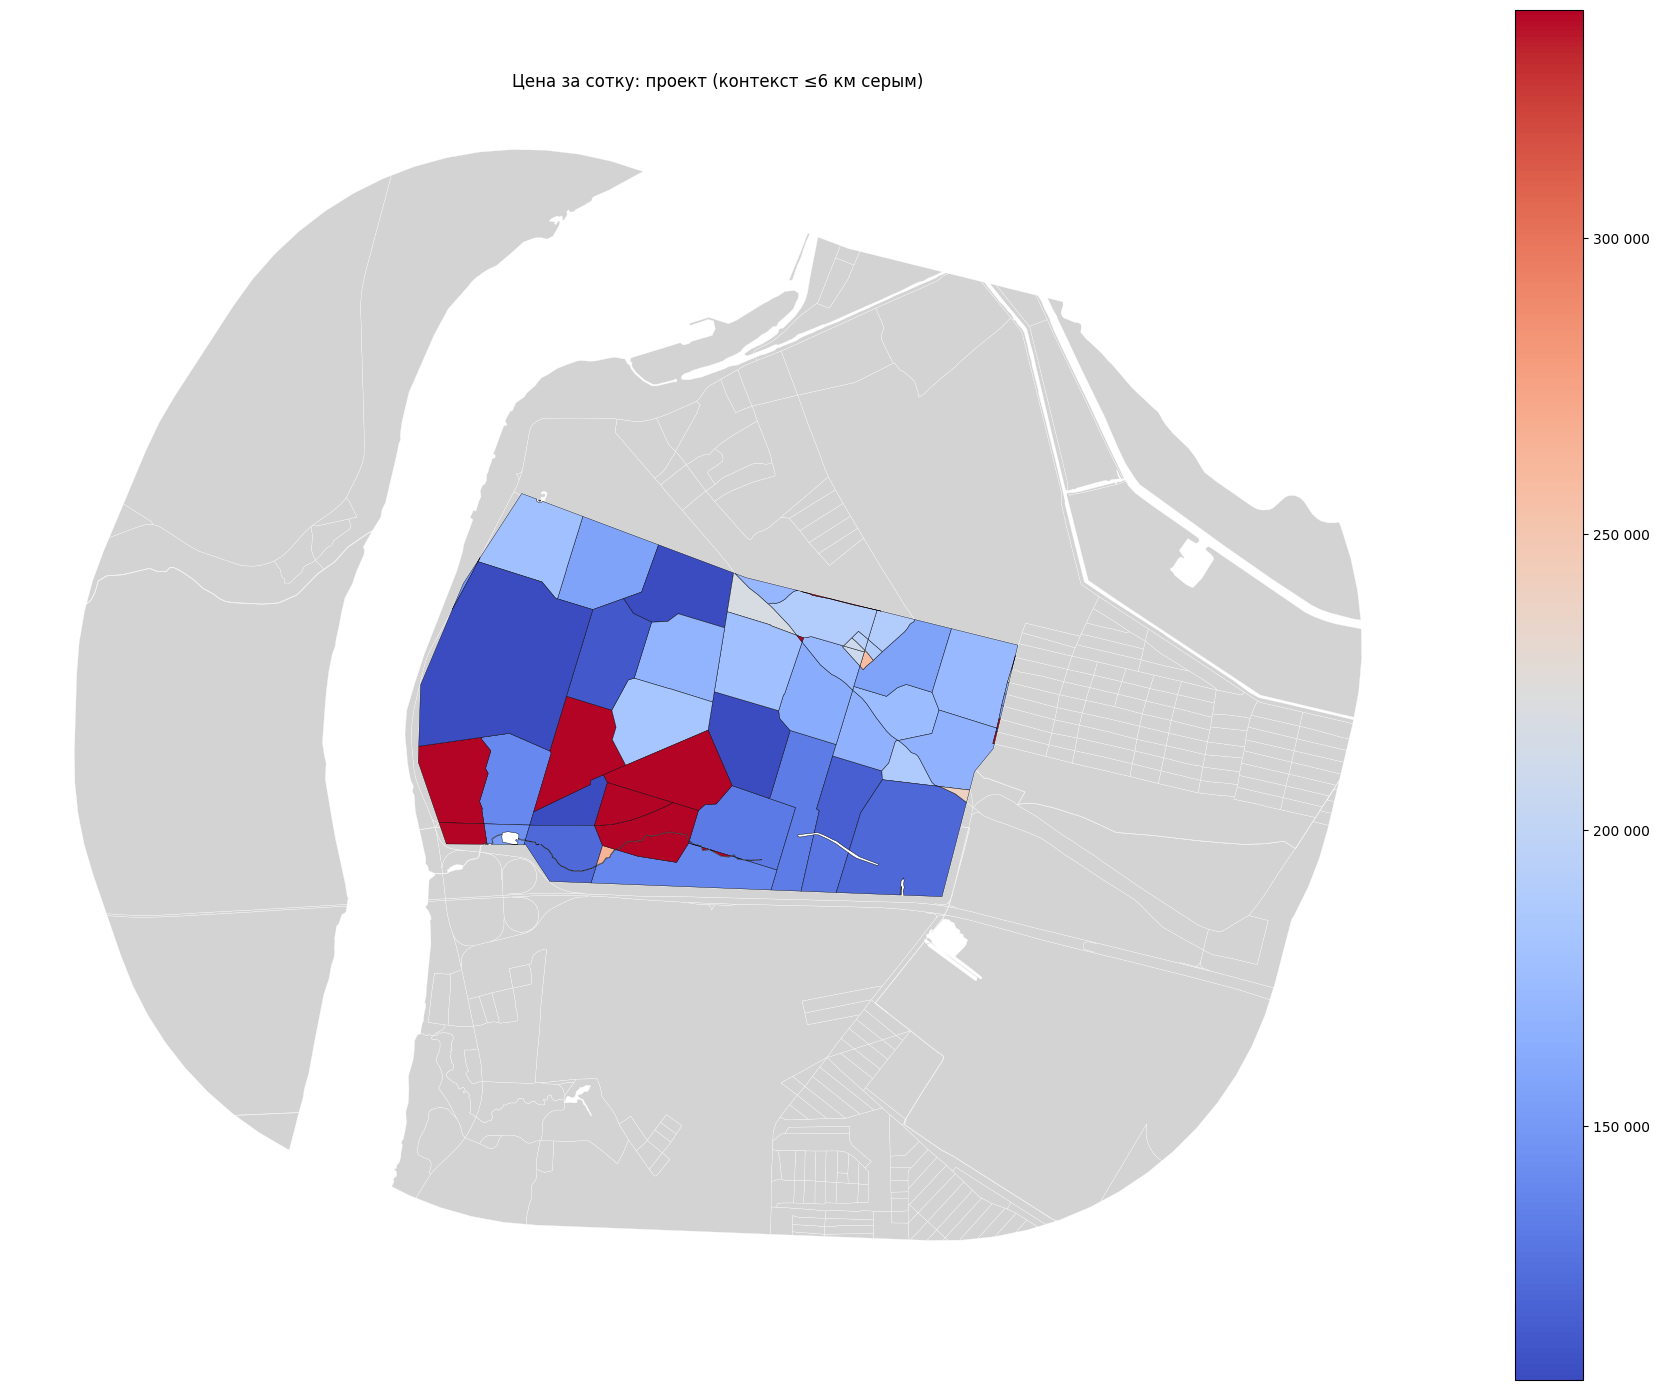

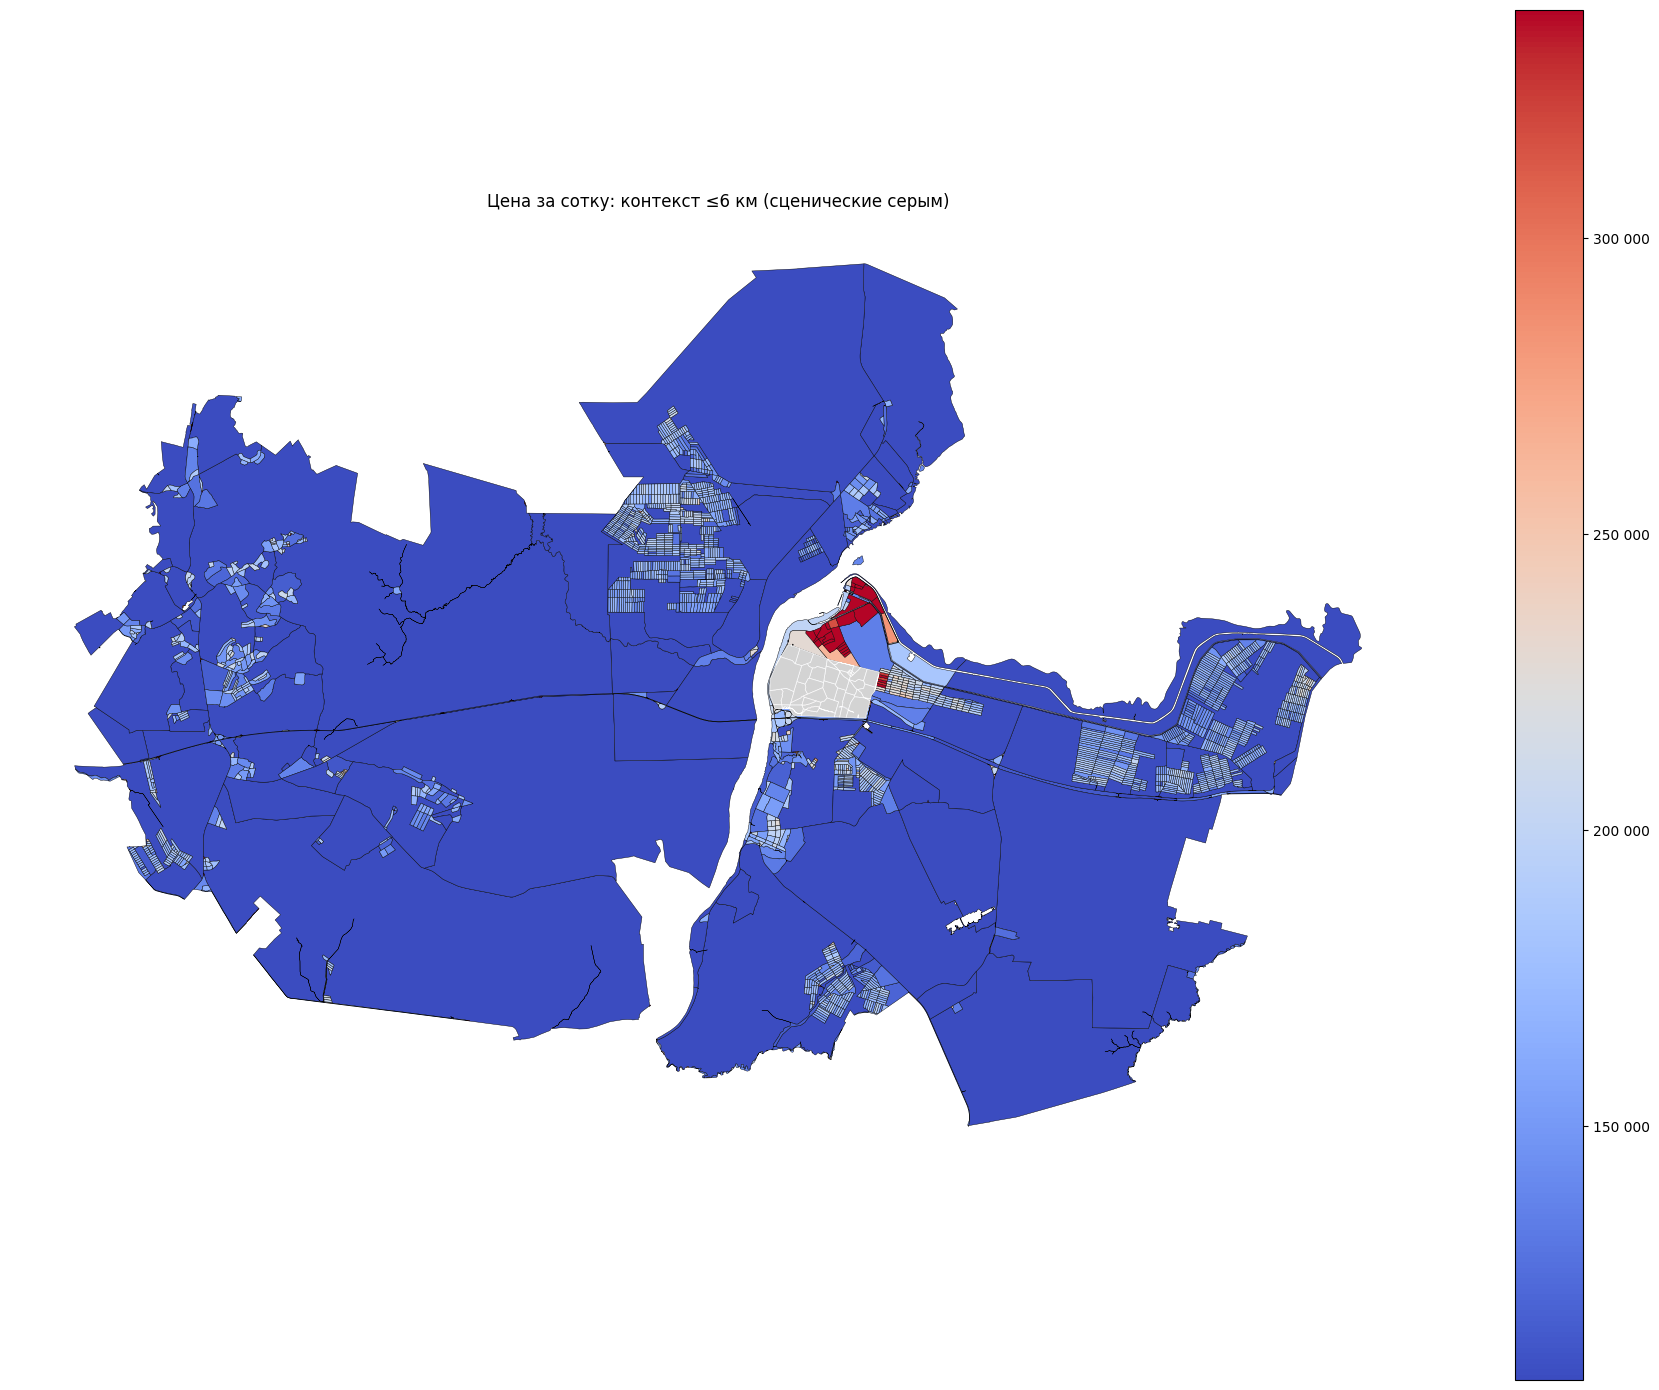

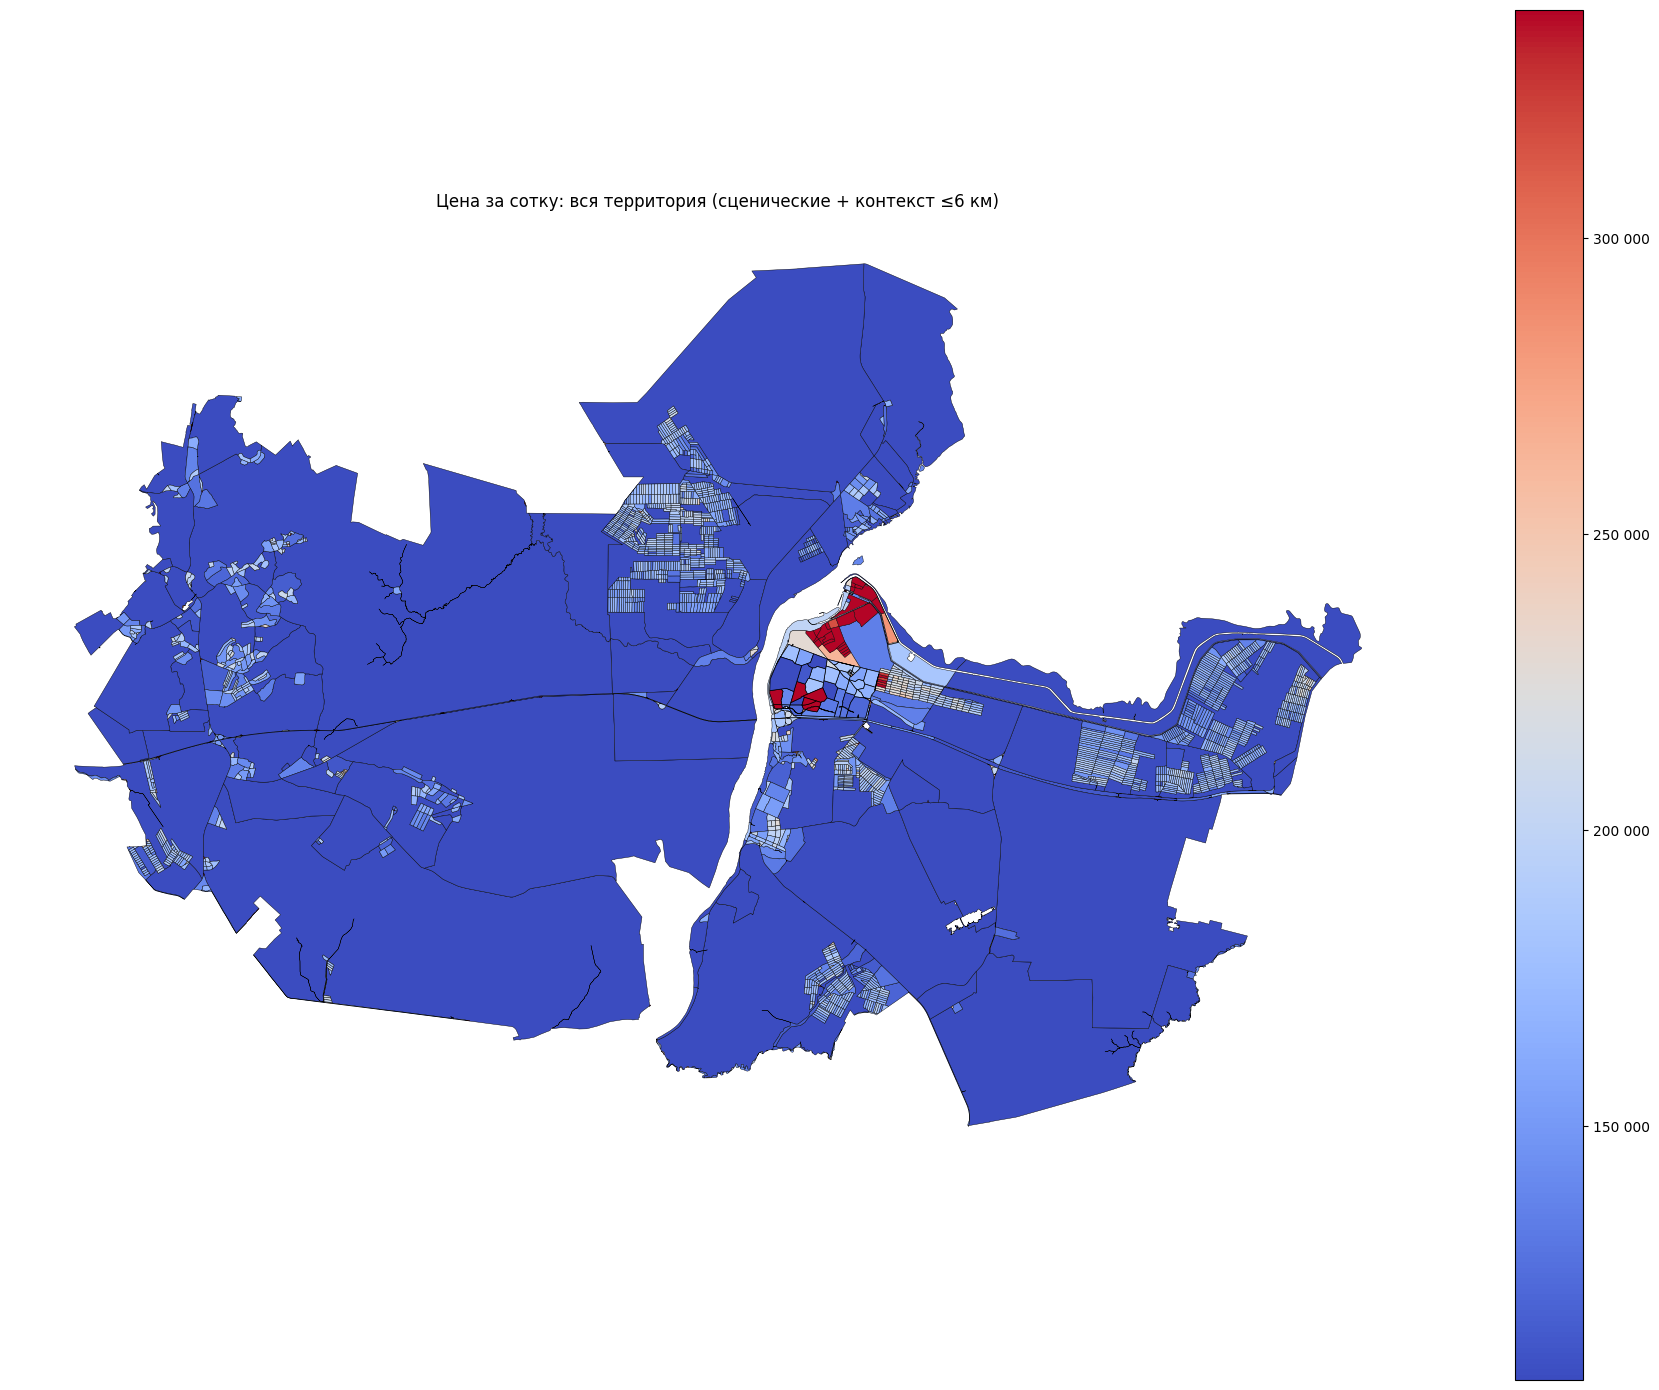

In [5]:
from urbanomy.methods.land_value_modeling import plot_land_price_maps

visualization_output = plot_land_price_maps(
    blocks_pred=blocks_pred,
    scenario_blocks=scenario_blocks,
    buffer_radius_m=2000,
)



In [6]:
blocks_pred.to_pickle('../data/blocks_with_price.pickle')

# Сценарное изменение ТЭП участков

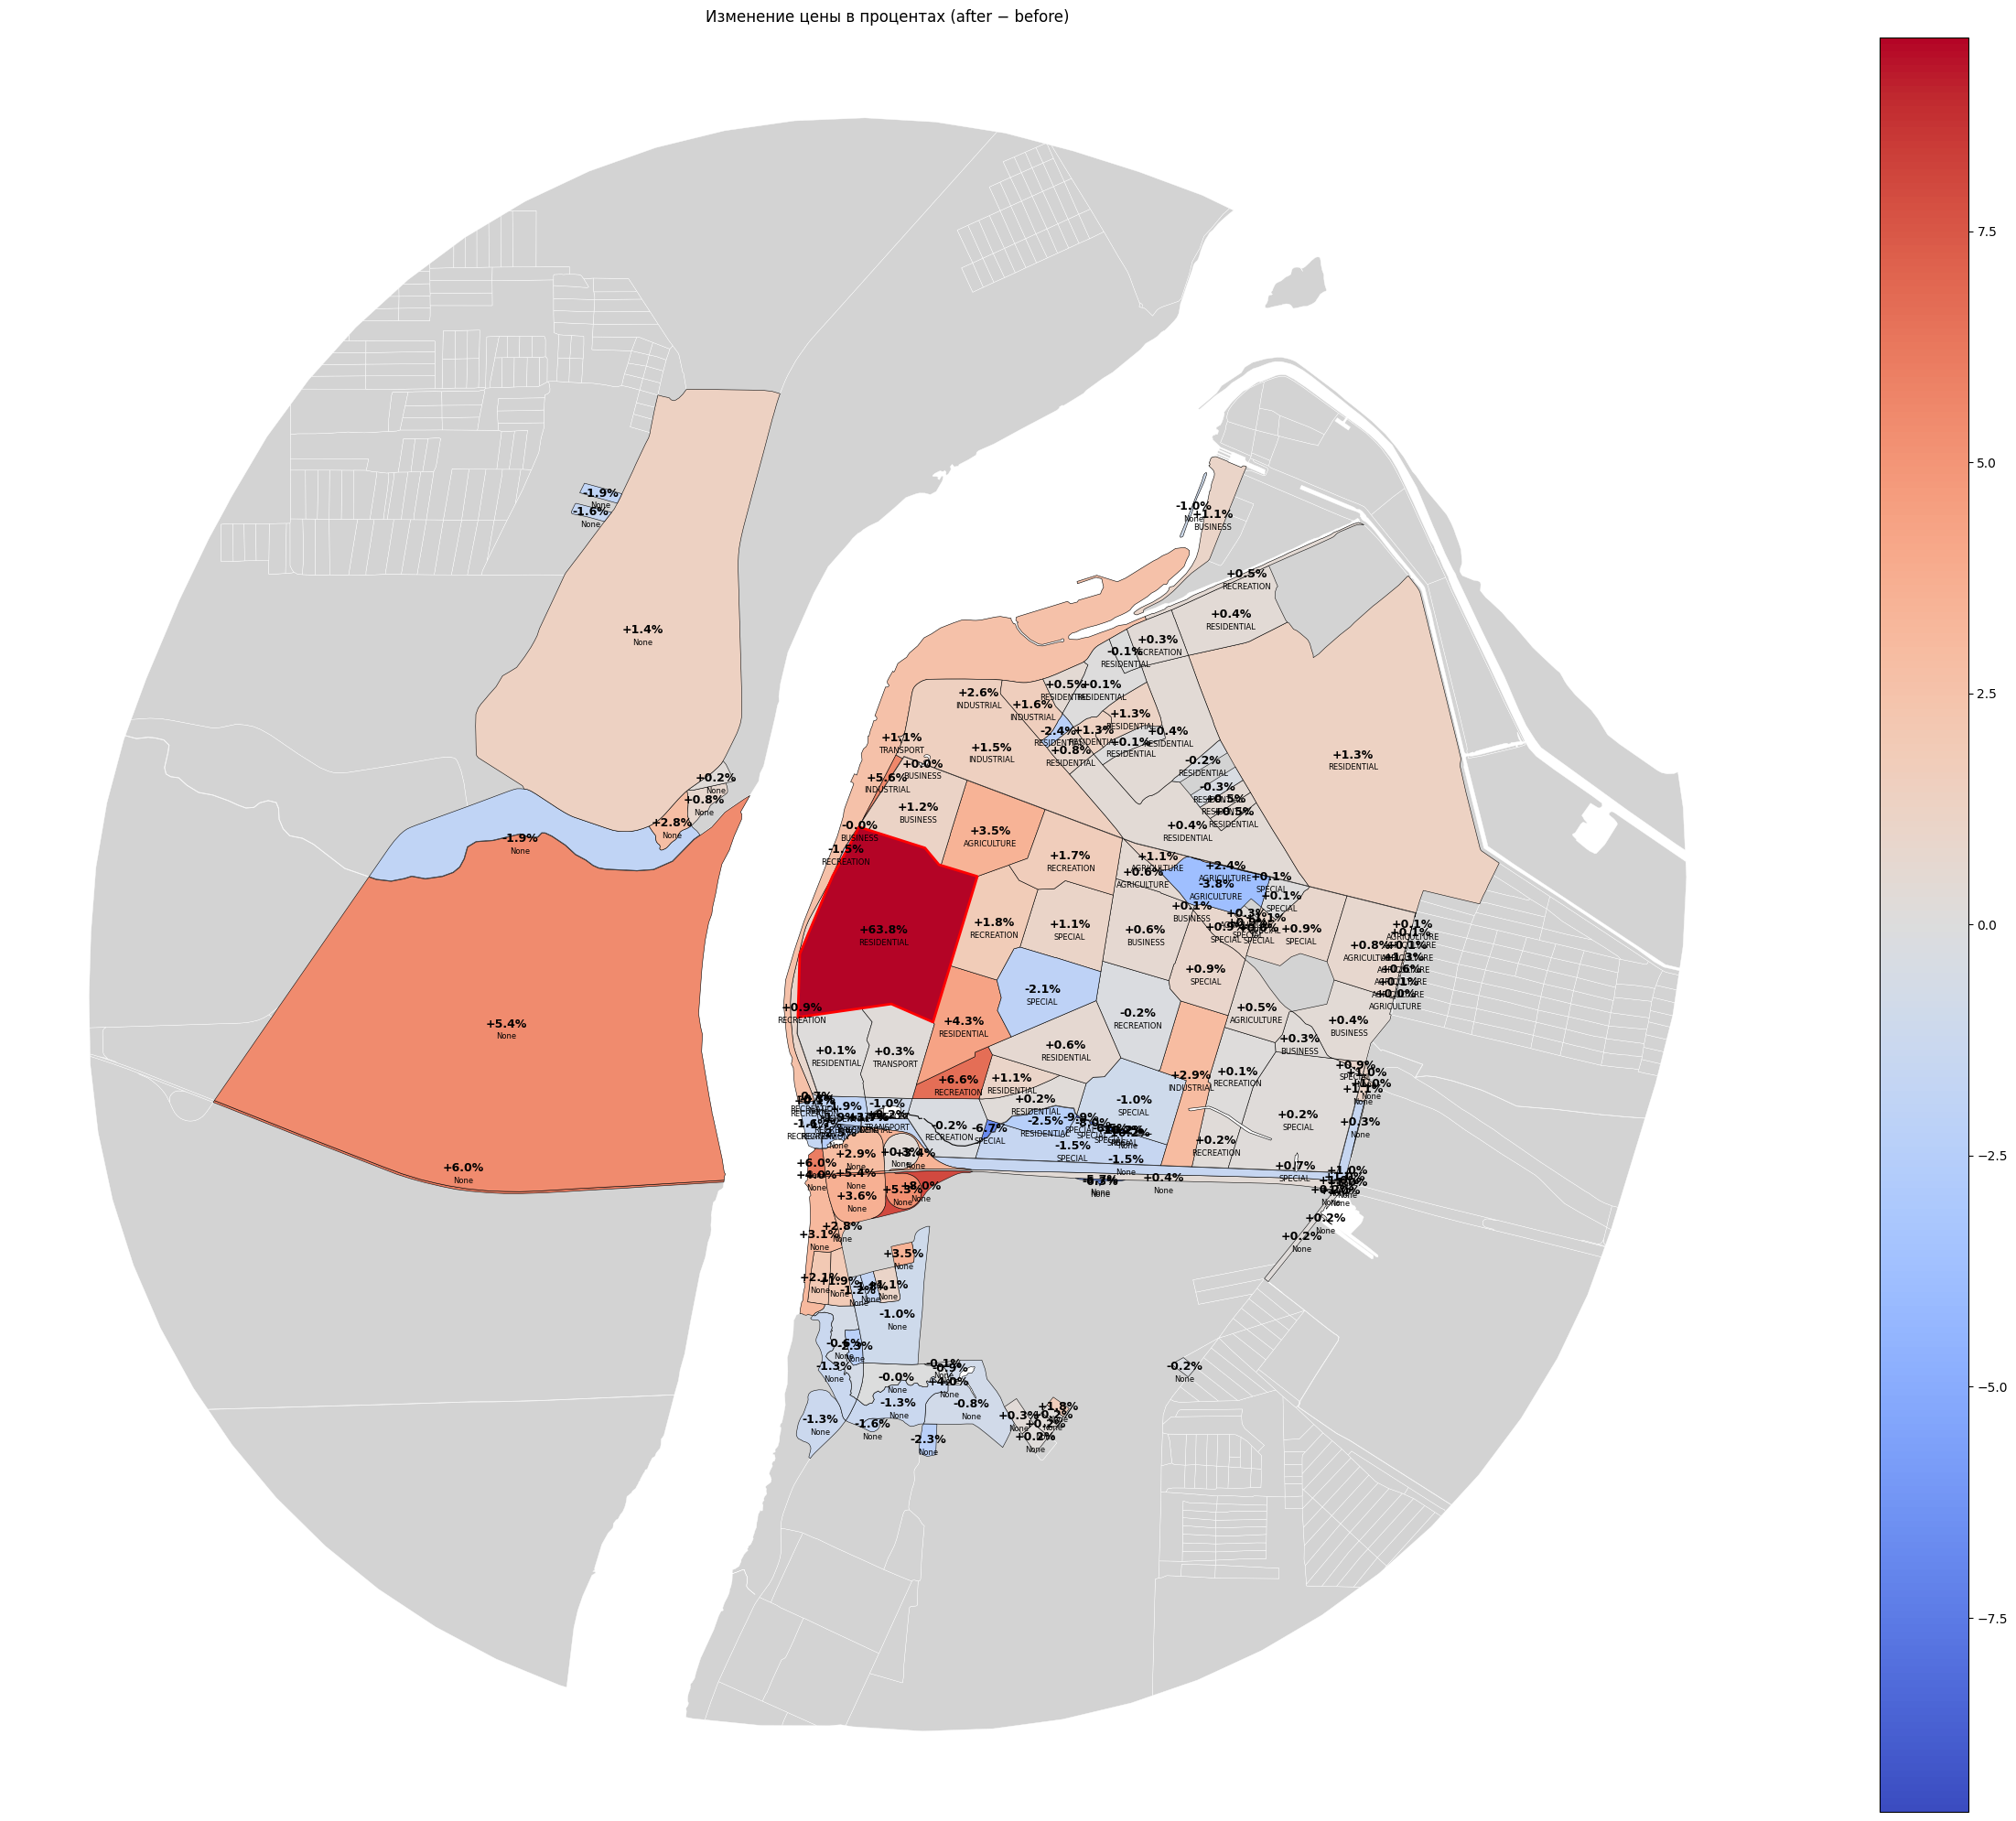


Статистика по кварталам в пределах буфера (|Δ₽| > 1e-09):
index | до (₽) → после (₽) | Δ₽ | Δ%
377 | 129 323 ₽ → 130 645 ₽ | +1 322 ₽ | +1.0%
387 | 122 815 ₽ → 124 071 ₽ | +1 256 ₽ | +1.0%
388 | 3 088 054 ₽ → 3 119 629 ₽ | +31 575 ₽ | +1.0%
1421 | 124 732 ₽ → 126 008 ₽ | +1 275 ₽ | +1.0%
1450 | 136 063 ₽ → 137 454 ₽ | +1 391 ₽ | +1.0%
1568 | 17 066 980 ₽ → 17 369 076 ₽ | +302 096 ₽ | +1.8%
1525 | 32 348 239 ₽ → 32 415 549 ₽ | +67 309 ₽ | +0.2%
1559 | 16 434 398 ₽ → 16 405 575 ₽ | -28 823 ₽ | -0.2%
614 | 2 162 540 ₽ → 2 026 371 ₽ | -136 168 ₽ | -6.3%
326 | 107 354 595 ₽ → 107 777 167 ₽ | +422 571 ₽ | +0.4%
378 | 6 333 778 ₽ → 5 970 624 ₽ | -363 154 ₽ | -5.7%
12 | 250 619 914 ₽ → 246 801 161 ₽ | -3 818 753 ₽ | -1.5%
325 | 251 739 060 ₽ → 247 895 904 ₽ | -3 843 157 ₽ | -1.5%
48 | 65 666 ₽ → 58 959 ₽ | -6 707 ₽ | -10.2%
49 | 67 828 ₽ → 60 900 ₽ | -6 928 ₽ | -10.2%
1451 | 6 844 455 ₽ → 6 862 224 ₽ | +17 769 ₽ | +0.3%
617 | 15 570 622 ₽ → 15 740 873 ₽ | +170 251 ₽ | +1.1%
2552 | 4 229 055 ₽

In [7]:
from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    plot_scenario_impact,
)

blocks_before = blocks
changes = {
    'land_use': 'RESIDENTIAL',
    'share': 0.95,
    'footprint_area': 49039.24,
    'build_floor_area': 230279.19,
    'living_area': 155896.85,
    'population': 5168
}
target_idx = 62

modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_idx, changes)

scenario_result = plot_scenario_impact(
    blocks_before=blocks_before,
    blocks_after=blocks_after,
    model=model,
    target_idx=target_idx,
)

